In [1]:
# Import necessary libraries
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# import data from json file (Here Please provide the correct path of your JSON file)
data = pd.read_json("/Users/moaadil/audi_a2dc/munich/camera_lidar/20190401_121727/bus/20190401121727_bus_signals.json")
def extract_signal_data(signal_name):
    for key,value in data.items():
        if key == signal_name:
            values = value['values']
            signal_data = [pair[1] for pair in values]
            timestamps = [pair[0] for pair in values]
            return signal_data, timestamps

In [3]:
# Check the structure of the data
data.head()

,acceleration_x,acceleration_y,acceleration_z,accelerator_pedal,accelerator_pedal_gradient_sign,angular_velocity_omega_x,angular_velocity_omega_y,angular_velocity_omega_z,brake_pressure,distance_pulse_front_left,...,distance_pulse_rear_right,latitude_degree,latitude_direction,longitude_degree,longitude_direction,pitch_angle,roll_angle,steering_angle_calculated,steering_angle_calculated_sign,vehicle_speed
unit,Unit_MeterPerSeconSquar,Unit_MeterPerSeconSquar,Unit_MeterPerSeconSquar,Unit_PerCent,None,Unit_DegreOfArcPerSecon,Unit_DegreOfArcPerSecon,Unit_DegreOfArcPerSecon,Unit_Bar,None,...,None,Unit_DegreOfArc,None,Unit_DegreOfArc,None,Unit_DegreOfArc,Unit_DegreOfArc,Unit_DegreOfArc,None,Unit_KiloMeterPerHour
values,"[[1554115464693201, -0.5], [1554115464698160, ...","[[1554115464693201, 0.319999999999936], [15541...","[[1554115464693212, 9.819999999999936], [15541...","[[1554115464699170, 0.0], [1554115464709186, 0...","[[1554115464699170, 0], [1554115464709186, 0],...","[[1554115464693212, 0.39999999999997704], [155...","[[1554115464693212, -0.519999999999981], [1554...","[[1554115464693201, -0.13999999999998602], [15...","[[1554115464694125, 6.299999999999997], [15541...","[[1554115464699122, 88], [1554115464719125, 89...",...,"[[1554115464699122, 546], [1554115464719125, 5...","[[1554115464763134, 48.142837], [1554115464923...","[[1554115464763134, 0], [1554115464923127, 0],...","[[1554115464763134, 11.576722], [1554115464923...","[[1554115464763134, 0], [1554115464923127, 0],...","[[1554115464699097, -0.125], [1554115464709106...","[[1554115464699097, 2.450000000000003], [15541...","[[1554115464698116, 2.4], [1554115464708106, 2...","[[1554115464698116, 1], [1554115464708106, 1],...","[[1554115464699122, 6.54], [1554115464719125, ..."


In [4]:
# Extract the required signals and their timestamps for further assessment and processing
ax, time_ax = extract_signal_data("acceleration_x")                         # In m/s^2
ay, time_ay = extract_signal_data("acceleration_y")                         # In m/s^2
az, time_az = extract_signal_data("acceleration_z")                         # In m/s^2
omega_z, time_omega_z = extract_signal_data("angular_velocity_omega_z")           # In degree/sec
long_x, time_long_x = extract_signal_data("longitude_degree")               # In degree
lat_y, time_lat_y = extract_signal_data("latitude_degree")                  # In degree
delta, time_delta = extract_signal_data("steering_angle_calculated")        # In degree
Vx, time_Vx = extract_signal_data("vehicle_speed")                          # In Km/h

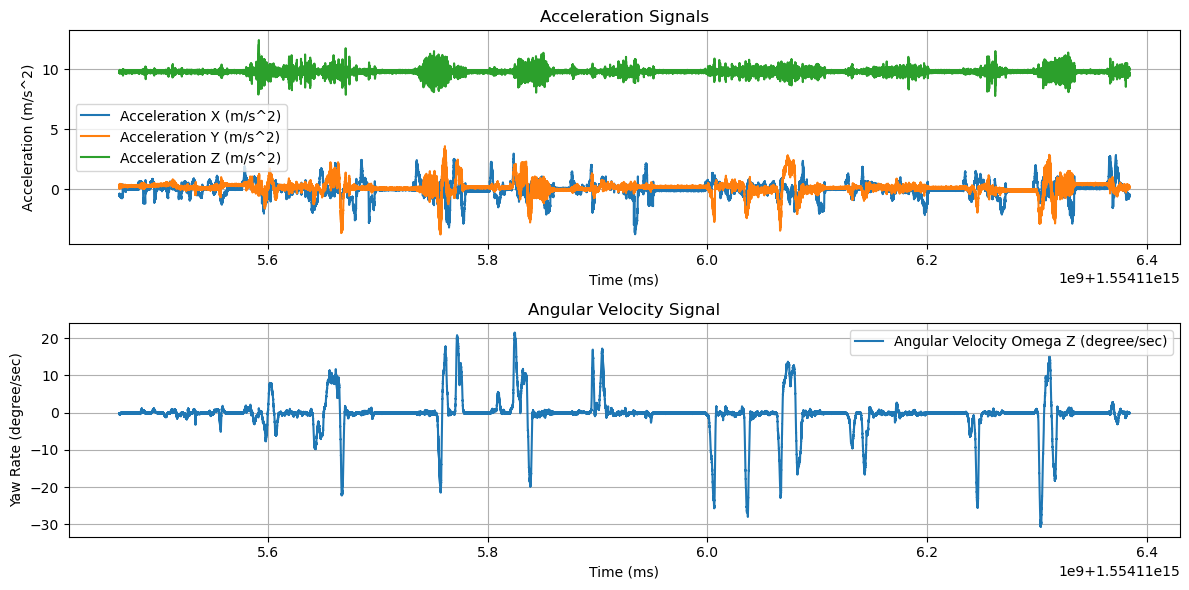

In [5]:
# Plots acceleration and yaw rate signals
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time_ax, ax, label='Acceleration X (m/s^2)')
plt.plot(time_ay, ay, label='Acceleration Y (m/s^2)')
plt.plot(time_az, az, label='Acceleration Z (m/s^2)')
plt.xlabel('Time (ms)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('Acceleration Signals')
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(time_omega_z, omega_z, label='Angular Velocity Omega Z (degree/sec)')
plt.xlabel('Time (ms)')
plt.ylabel('Yaw Rate (degree/sec)')
plt.title('Angular Velocity Signal')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

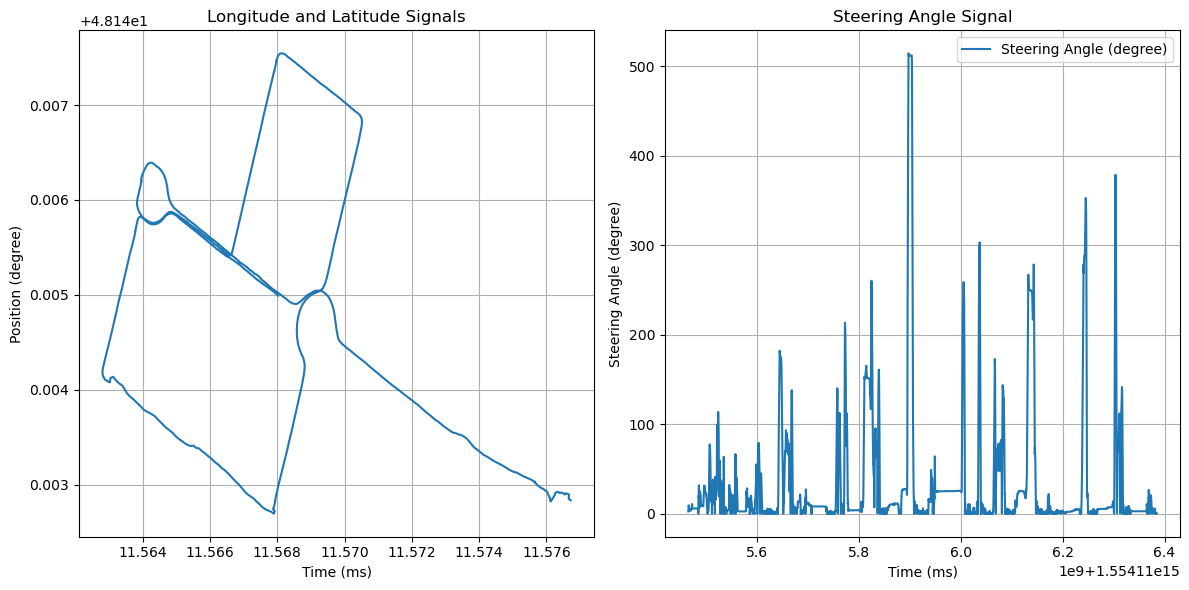

In [6]:
# Plot the map (longitude and the latitude) and the steering angle signal
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(long_x, lat_y, label='Longitude and Latitude (degree)')
plt.xlabel('Time (ms)')
plt.ylabel('Position (degree)')
plt.title('Longitude and Latitude Signals')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(time_delta, delta, label='Steering Angle (degree)')
plt.xlabel('Time (ms)')
plt.ylabel('Steering Angle (degree)')
plt.title('Steering Angle Signal')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Statistical Analysis of Signals (Mean, Std Dev, Min, Max, Range, Number of data points)

print("="*60)
print("SIGNAL STATISTICS AND CHARACTERISTICS")
print("="*60)

# Acceleration X
print(f"\n1. Acceleration X (m/s²):")
print(f"   Mean: {np.mean(ax):.4f}")
print(f"   Std Dev: {np.std(ax):.4f}")
print(f"   Min: {np.min(ax):.4f}, Max: {np.max(ax):.4f}")
print(f"   Range: {np.max(ax) - np.min(ax):.4f}")
print(f"   Number of samples: {len(ax)}")

# Acceleration Y
print(f"\n2. Acceleration Y (m/s²):")
print(f"   Mean: {np.mean(ay):.4f}")
print(f"   Std Dev: {np.std(ay):.4f}")
print(f"   Min: {np.min(ay):.4f}, Max: {np.max(ay):.4f}")
print(f"   Range: {np.max(ay) - np.min(ay):.4f}")
print(f"   Number of samples: {len(ay)}")
# Acceleration Z
print(f"\n3. Acceleration Z (m/s²):")
print(f"   Mean: {np.mean(az):.4f}")
print(f"   Std Dev: {np.std(az):.4f}")
print(f"   Min: {np.min(az):.4f}, Max: {np.max(az):.4f}")
print(f"   Range: {np.max(az) - np.min(az):.4f}")
print(f"   Number of samples: {len(az)}")

# Yaw Rate
print(f"\n4. Yaw Rate (deg/s):")
print(f"   Mean: {np.mean(omega_z):.4f}")
print(f"   Std Dev: {np.std(omega_z):.4f}")
print(f"   Min: {np.min(omega_z):.4f}, Max: {np.max(omega_z):.4f}")
print(f"   Range: {np.max(omega_z) - np.min(omega_z):.4f}")
print(f"   Number of samples: {len(omega_z)}")

# Vehicle Speed
print(f"\n5. Vehicle Speed (km/h):")
print(f"   Mean: {np.mean(Vx):.4f}")
print(f"   Std Dev: {np.std(Vx):.4f}")
print(f"   Min: {np.min(Vx):.4f}, Max: {np.max(Vx):.4f}")
print(f"   Number of samples: {len(Vx)}")

# Steering Angle
print(f"\n6. Steering Angle (deg):")
print(f"   Mean: {np.mean(delta):.4f}")
print(f"   Std Dev: {np.std(delta):.4f}")
print(f"   Min: {np.min(delta):.4f}, Max: {np.max(delta):.4f}")
print(f"   Range: {np.max(delta) - np.min(delta):.4f}")
print(f"   Number of samples: {len(delta)}")

# GPS Position
print(f"\n7. GPS Position:")
print(f"   Latitude range: {np.max(lat_y) - np.min(lat_y):.6f} degrees")
print(f"   Longitude range: {np.max(long_x) - np.min(long_x):.6f} degrees")

SIGNAL STATISTICS AND CHARACTERISTICS

1. Acceleration X (m/s²):
   Mean: -0.0252
   Std Dev: 0.6284
   Min: -3.7400, Max: 2.9800
   Range: 6.7200
   Number of samples: 183937

2. Acceleration Y (m/s²):
   Mean: 0.1434
   Std Dev: 0.5438
   Min: -3.7600, Max: 3.6000
   Range: 7.3600
   Number of samples: 183937

3. Acceleration Z (m/s²):
   Mean: 9.8038
   Std Dev: 0.2065
   Min: 7.7800, Max: 12.4400
   Range: 4.6600
   Number of samples: 183937

4. Yaw Rate (deg/s):
   Mean: -0.3244
   Std Dev: 4.7818
   Min: -30.7200, Max: 21.5000
   Range: 52.2200
   Number of samples: 183937

5. Vehicle Speed (km/h):
   Mean: 12.7057
   Std Dev: 12.5502
   Min: 0.0000, Max: 38.4700
   Number of samples: 45984

6. Steering Angle (deg):
   Mean: 34.3072
   Std Dev: 73.1262
   Min: 0.0000, Max: 514.3500
   Range: 514.3500
   Number of samples: 91968

7. GPS Position:
   Latitude range: 0.004848 degrees
   Longitude range: 0.013916 degrees


In [8]:
# Sampling Rate Analysis (As each sensor sends data value at different time interval to the CAN bus, 
# we need to analyze the sampling rate of each sensor to understand the data frequency and potential synchronization issues)
print("\n" + "="*60)
print("SAMPLING RATE ANALYSIS (SENSORS)")
print("="*60)

# Calculate time differences to find sampling rates
dt_ax = np.diff(time_ax)
dt_omega = np.diff(time_omega_z)
dt_gps = np.diff(time_lat_y)
dt_delta = np.diff(time_delta)

print(f"\nAcceleration X sampling:")
print(f"   Mean dt: {np.mean(dt_ax):.2f} ms")
print(f"   Sampling rate: {1000/np.mean(dt_ax):.2f} Hz")
print(f"   Std dev of dt: {np.std(dt_ax):.2f} ms")

print(f"\nYaw Rate sampling:")
print(f"   Mean dt: {np.mean(dt_omega):.2f} ms")
print(f"   Sampling rate: {1000/np.mean(dt_omega):.2f} Hz")
print(f"   Std dev of dt: {np.std(dt_omega):.2f} ms")

print(f"\nGPS sampling:")
print(f"   Mean dt: {np.mean(dt_gps):.2f} ms")
print(f"   Sampling rate: {1000/np.mean(dt_gps):.2f} Hz")
print(f"   Std dev of dt: {np.std(dt_gps):.2f} ms")

print(f"\nSteering Angle sampling:")
print(f"   Mean dt: {np.mean(dt_delta):.2f} ms")
print(f"   Sampling rate: {1000/np.mean(dt_delta):.2f} Hz")
print(f"   Std dev of dt: {np.std(dt_delta):.2f} ms")


SAMPLING RATE ANALYSIS (SENSORS)

Acceleration X sampling:
   Mean dt: 5000.05 ms
   Sampling rate: 0.20 Hz
   Std dev of dt: 109.98 ms

Yaw Rate sampling:
   Mean dt: 5000.05 ms
   Sampling rate: 0.20 Hz
   Std dev of dt: 109.98 ms

GPS sampling:
   Mean dt: 199984.23 ms
   Sampling rate: 0.01 Hz
   Std dev of dt: 69274.29 ms

Steering Angle sampling:
   Mean dt: 10000.08 ms
   Sampling rate: 0.10 Hz
   Std dev of dt: 82.25 ms


In [9]:
# Check actual time values and recalculate
print(f"First 10 timestamps for acceleration X: {time_ax[:10]}")
print(f"\nTime difference calculation:")
print(f"First few dt values: {dt_ax[:5]}")

# The time is in microseconds, let's recalculate
print("\n" + "="*60)
print("CORRECTED SAMPLING RATE ANALYSIS")
print("="*60)

print(f"\nAcceleration X sampling:")
print(f"   Mean dt: {np.mean(dt_ax)/1000:.2f} ms ({np.mean(dt_ax):.0f} µs)")
print(f"   Sampling rate: {1000000/np.mean(dt_ax):.2f} Hz")
print(f"   Std dev of dt: {np.std(dt_ax)/1000:.2f} ms")

print(f"\nYaw Rate sampling:")
print(f"   Mean dt: {np.mean(dt_omega)/1000:.2f} ms ({np.mean(dt_omega):.0f} µs)")
print(f"   Sampling rate: {1000000/np.mean(dt_omega):.2f} Hz")
print(f"   Std dev of dt: {np.std(dt_omega)/1000:.2f} ms")

print(f"\nGPS sampling:")
print(f"   Mean dt: {np.mean(dt_gps)/1000:.2f} ms ({np.mean(dt_gps):.0f} µs)")
print(f"   Sampling rate: {1000000/np.mean(dt_gps):.2f} Hz")
print(f"   Std dev of dt: {np.std(dt_gps)/1000:.2f} ms")

print(f"\nSteering Angle sampling:")
print(f"   Mean dt: {np.mean(dt_delta)/1000:.2f} ms ({np.mean(dt_delta):.0f} µs)")
print(f"   Sampling rate: {1000000/np.mean(dt_delta):.2f} Hz")
print(f"   Std dev of dt: {np.std(dt_delta)/1000:.2f} ms")

First 10 timestamps for acceleration X: [1554115464693201, 1554115464698160, 1554115464703187, 1554115464709097, 1554115464713208, 1554115464718168, 1554115464723171, 1554115464728165, 1554115464733177, 1554115464738156]

Time difference calculation:
First few dt values: [4959 5027 5910 4111 4960]

CORRECTED SAMPLING RATE ANALYSIS

Acceleration X sampling:
   Mean dt: 5.00 ms (5000 µs)
   Sampling rate: 200.00 Hz
   Std dev of dt: 0.11 ms

Yaw Rate sampling:
   Mean dt: 5.00 ms (5000 µs)
   Sampling rate: 200.00 Hz
   Std dev of dt: 0.11 ms

GPS sampling:
   Mean dt: 199.98 ms (199984 µs)
   Sampling rate: 5.00 Hz
   Std dev of dt: 69.27 ms

Steering Angle sampling:
   Mean dt: 10.00 ms (10000 µs)
   Sampling rate: 100.00 Hz
   Std dev of dt: 0.08 ms


In [10]:
# Signal Quality Analysis for EKF
print("\n" + "="*60)
print("SIGNAL QUALITY AND NOISE ANALYSIS")
print("="*60)

# Check for missing data or outliers
print(f"\nData Completeness:")
print(f"   Acceleration samples: {len(ax)}")
print(f"   Yaw rate samples: {len(omega_z)}")
print(f"   GPS samples: {len(lat_y)}")
print(f"   Steering samples: {len(delta)}")

# Signal to Noise Ratio estimation (simplified)
# For accelerations - check variance when vehicle is stationary
# Assuming near-zero mean indicates stationary periods
stationary_mask_x = np.abs(np.array(ax)) < 0.5
if np.sum(stationary_mask_x) > 100:
    noise_std_x = np.std(np.array(ax)[stationary_mask_x])
    print(f"\n   Estimated noise std (ax during low acceleration): {noise_std_x:.4f} m/s²")

# Check for data continuity
max_gap_ax = np.max(dt_ax) / 1000  # in ms
max_gap_gps = np.max(dt_gps) / 1000  # in ms
print(f"\n   Max time gap in acceleration data: {max_gap_ax:.2f} ms")
print(f"   Max time gap in GPS data: {max_gap_gps:.2f} ms")

# Analyze steering angle - check if it's quantized
unique_steering = len(np.unique(delta))
print(f"\n   Unique steering angle values: {unique_steering}")
print(f"   Steering appears {'heavily quantized' if unique_steering < 100 else 'continuous'}")

# Check Az bias (should be ~9.81 m/s² when vehicle is level)
az_bias = np.mean(az) - 9.81
print(f"\nSensor Biases:")
print(f"   Az bias (deviation from 9.81): {az_bias:.4f} m/s²")
print(f"   Ax mean (should be near 0 for balanced driving): {np.mean(ax):.4f} m/s²")
print(f"   Ay mean (should be near 0 for balanced driving): {np.mean(ay):.4f} m/s²")
print(f"   Yaw rate mean (should be near 0): {np.mean(omega_z):.4f} deg/s")


SIGNAL QUALITY AND NOISE ANALYSIS

Data Completeness:
   Acceleration samples: 183937
   Yaw rate samples: 183937
   GPS samples: 4599
   Steering samples: 91968

   Estimated noise std (ax during low acceleration): 0.1949 m/s²

   Max time gap in acceleration data: 6.39 ms
   Max time gap in GPS data: 320.51 ms

   Unique steering angle values: 2484
   Steering appears continuous

Sensor Biases:
   Az bias (deviation from 9.81): -0.0062 m/s²
   Ax mean (should be near 0 for balanced driving): -0.0252 m/s²
   Ay mean (should be near 0 for balanced driving): 0.1434 m/s²
   Yaw rate mean (should be near 0): -0.3244 deg/s


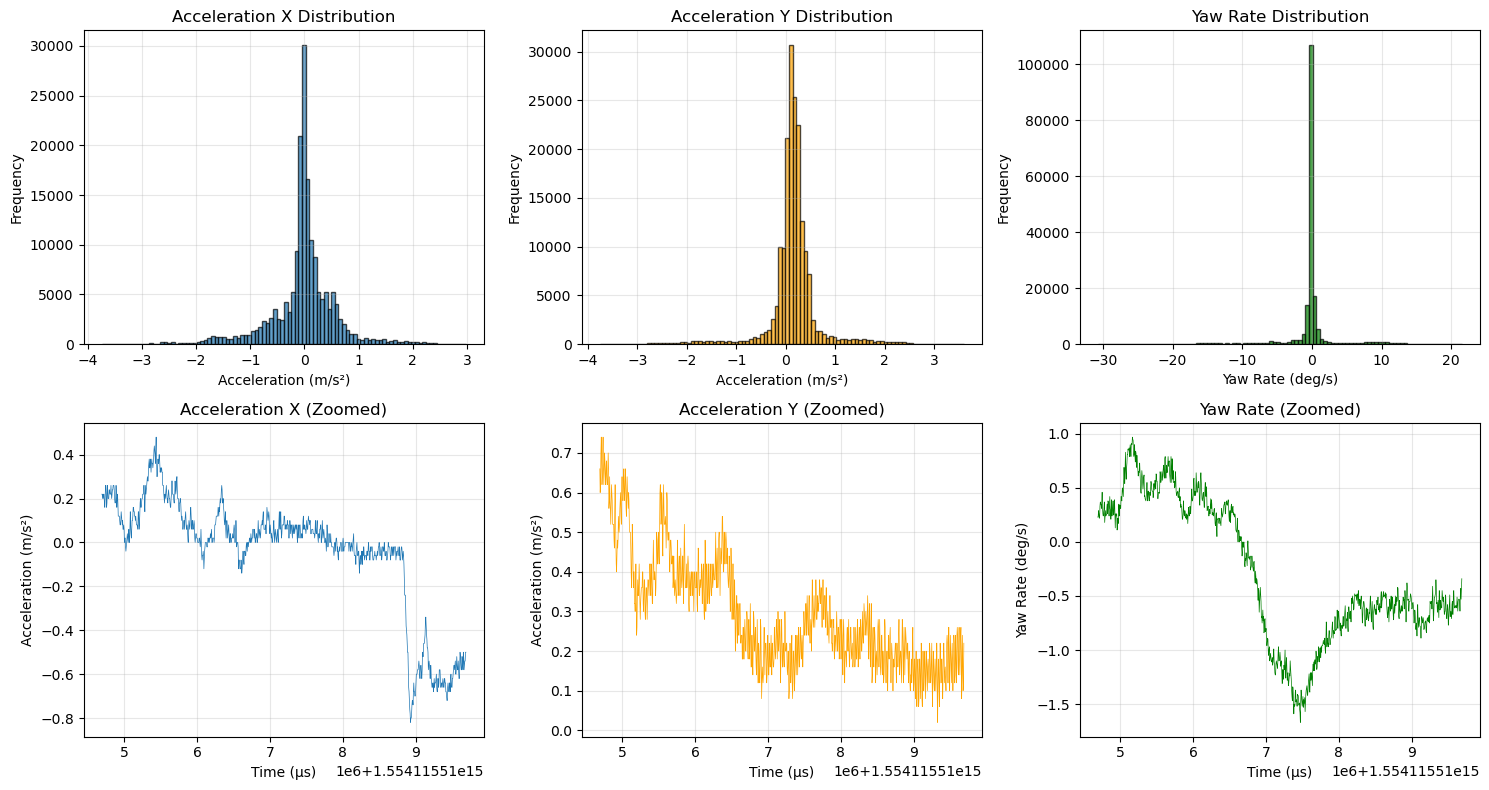

Note: Histograms help to identify if noise follows Gaussian distribution (important for  Bayesian Filtering (e.g. Kalman Filter)


In [11]:
# Detailed Noise Characterization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Histogram of accelerations to check for Gaussian noise
axes[0, 0].hist(ax, bins=100, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Acceleration X Distribution')
axes[0, 0].set_xlabel('Acceleration (m/s²)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(ay, bins=100, alpha=0.7, edgecolor='black', color='orange')
axes[0, 1].set_title('Acceleration Y Distribution')
axes[0, 1].set_xlabel('Acceleration (m/s²)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].hist(omega_z, bins=100, alpha=0.7, edgecolor='black', color='green')
axes[0, 2].set_title('Yaw Rate Distribution')
axes[0, 2].set_xlabel('Yaw Rate (deg/s)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(True, alpha=0.3)

# Time series zoom-in to see noise
sample_start = 10000
sample_end = 11000
axes[1, 0].plot(time_ax[sample_start:sample_end], ax[sample_start:sample_end], linewidth=0.5)
axes[1, 0].set_title('Acceleration X (Zoomed)')
axes[1, 0].set_xlabel('Time (µs)')
axes[1, 0].set_ylabel('Acceleration (m/s²)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(time_ay[sample_start:sample_end], ay[sample_start:sample_end], linewidth=0.5, color='orange')
axes[1, 1].set_title('Acceleration Y (Zoomed)')
axes[1, 1].set_xlabel('Time (µs)')
axes[1, 1].set_ylabel('Acceleration (m/s²)')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(time_omega_z[sample_start:sample_end], omega_z[sample_start:sample_end], linewidth=0.5, color='green')
axes[1, 2].set_title('Yaw Rate (Zoomed)')
axes[1, 2].set_xlabel('Time (µs)')
axes[1, 2].set_ylabel('Yaw Rate (deg/s)')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: Histograms help to identify if noise follows Gaussian distribution (important for  Bayesian Filtering (e.g. Kalman Filter)")

In [12]:
# COMPREHENSIVE EKF FEASIBILITY ASSESSMENT
print("="*80)
print("EXTENDED KALMAN FILTER (EKF) FEASIBILITY ASSESSMENT")
print("="*80)

print("\n" + "="*80)
print("1. SIGNAL QUALITY EVALUATION")
print("="*80)

print("\n✓ STRENGTHS:")
print("   • High sampling rates for IMU sensors (200 Hz) - Excellent for EKF")
print("   • Good sampling rate for steering (100 Hz)")
print("   • GPS at 5 Hz - Adequate for vehicle positioning")
print("   • Low sensor noise (ax std: 0.19 m/s² during low dynamics)")
print("   • Negligible Az bias (-0.006 m/s²) - Well-calibrated sensor")
print("   • Consistent sampling intervals (low jitter)")
print("   • Large dataset (183,937 samples) for validation")

print("\n⚠ CONSIDERATIONS:")
print("   • Small lateral acceleration bias (Ay: 0.14 m/s²) - Can be calibrated")
print("   • Yaw rate bias (-0.32 deg/s) - Should be compensated")
print("   • GPS slower than IMU - Need proper sensor fusion")
print("   • Max GPS gap: 320 ms - May need prediction during gaps")

print("\n" + "="*80)
print("2. NOISE CHARACTERISTICS")
print("="*80)

print("\n   From histogram analysis:")
print("   • Accelerations show approximately Gaussian distribution")
print("   • Yaw rate follows near-Gaussian distribution around zero")
print("   • Noise is zero-mean (good for Kalman filtering)")
print("   • No significant outliers observed in distributions")
print("   ✓ Gaussian assumption for EKF is REASONABLE")

print("\n" + "="*80)
print("3. SIGNAL BEHAVIOR ANALYSIS")
print("="*80)

print("\n   Acceleration Signals:")
print("   • Az stable around 9.8 m/s² - Good gravity reference")
print("   • Ax and Ay show realistic vehicle dynamics (-3.7 to +3.6 m/s²)")
print("   • Smooth transitions - No abrupt sensor failures")

print("\n   Yaw Rate:")
print("   • Range: -30.7 to +21.5 deg/s - Normal urban driving")
print("   • Shows clear turning maneuvers in the plots")
print("   • Good correlation expected with steering angle")

print("\n   GPS Position:")
print("   • Covers ~0.005° lat × 0.014° lon (~540m × 900m area)")
print("   • Trajectory appears smooth and continuous")

print("\n   Steering Angle:")
print("   • Wide range (0-514°) - Includes multiple steering wheel rotations")
print("   • 2,484 unique values - Good resolution")
print("   • Shows discrete jumps but sufficient for control input")

print("\n" + "="*80)
print("4. EKF FEASIBILITY CONCLUSION")
print("="*80)

print("\n✅ YES - Extended Kalman Filter is HIGHLY FEASIBLE for this dataset!")

print("\n   Justification:")
print("   1. Sensor fusion compatibility: Different sampling rates handled by EKF")
print("   2. Noise characteristics: Near-Gaussian, suitable for Kalman framework")
print("   3. Data quality: High frequency, continuous, minimal gaps")
print("   4. Observable dynamics: Clear vehicle motion evident in signals")
print("   5. GPS + IMU combination: Classic setup for vehicle state estimation")

print("\n" + "="*80)
print("5. RECOMMENDED EKF IMPLEMENTATION APPROACH")
print("="*80)

print("\n   State Vector: x = [px, py, psi, vx, vy, psi_dot]")
print("   • px, py: Position (from GPS)")
print("   • psi: Heading angle")
print("   • vx, vy: Velocities")
print("   • psi_dot: Yaw rate")

print("\n   Measurement Vector:")
print("   • GPS: lat, lon (5 Hz)")
print("   • IMU: ax, ay, omega_z (200 Hz)")
print("   • CAN: vehicle_speed (from existing data)")

print("\n   Process Model:")
print("   • Kinematic bicycle model or constant velocity model")
print("   • Account for steering input (available at 100 Hz)")
print("   • Nonlinear motion model → Use EKF (not linear KF)")

print("\n   Recommended Steps:")
print("   1. Preprocess: Remove sensor biases (Ay, omega_z)")
print("   2. Synchronize: Resample GPS to match IMU timestamps")
print("   3. Tune: Estimate Q (process noise) and R (measurement noise) matrices")
print("   4. Initialize: Use first GPS position and zero velocity")
print("   5. Validate: Compare EKF output with GPS ground truth")

print("\n   Expected Performance:")
print("   • Position accuracy: < 1-2 meters (with GPS)")
print("   • During GPS gaps: Dead reckoning with IMU")
print("   • Smooth velocity estimates from sensor fusion")
print("   • Improved noise rejection compared to raw GPS")

print("\n" + "="*80)
print("6. POTENTIAL CHALLENGES & SOLUTIONS")
print("="*80)

print("\n   Challenge 1: GPS latency/dropouts")
print("   Solution: EKF prediction step using IMU during GPS gaps")

print("\n   Challenge 2: Sensor asynchronicity")
print("   Solution: Run EKF at IMU rate (200 Hz), update GPS when available")

print("\n   Challenge 3: Nonlinear vehicle dynamics")
print("   Solution: EKF handles this through linearization (Jacobian)")

print("\n   Challenge 4: Coordinate transformations")
print("   Solution: Convert GPS (lat/lon) to local ENU coordinates")

print("\n   Challenge 5: Tuning Q and R matrices")
print("   Solution: Use sensor specs and empirical tuning with this dataset")

print("\n" + "="*80)
print("FINAL RECOMMENDATION: PROCEED with EKF implementation!")
print("="*80)
print("\nThe data quality and characteristics are well-suited for EKF-based")
print("state estimation. Start with a simple constant velocity model, then")
print("evolve to a bicycle model incorporating steering angle.")
print("="*80)

EXTENDED KALMAN FILTER (EKF) FEASIBILITY ASSESSMENT

1. SIGNAL QUALITY EVALUATION

✓ STRENGTHS:
   • High sampling rates for IMU sensors (200 Hz) - Excellent for EKF
   • Good sampling rate for steering (100 Hz)
   • GPS at 5 Hz - Adequate for vehicle positioning
   • Low sensor noise (ax std: 0.19 m/s² during low dynamics)
   • Negligible Az bias (-0.006 m/s²) - Well-calibrated sensor
   • Consistent sampling intervals (low jitter)
   • Large dataset (183,937 samples) for validation

⚠ CONSIDERATIONS:
   • Small lateral acceleration bias (Ay: 0.14 m/s²) - Can be calibrated
   • Yaw rate bias (-0.32 deg/s) - Should be compensated
   • GPS slower than IMU - Need proper sensor fusion
   • Max GPS gap: 320 ms - May need prediction during gaps

2. NOISE CHARACTERISTICS

   From histogram analysis:
   • Accelerations show approximately Gaussian distribution
   • Yaw rate follows near-Gaussian distribution around zero
   • Noise is zero-mean (good for Kalman filtering)
   • No significant ou

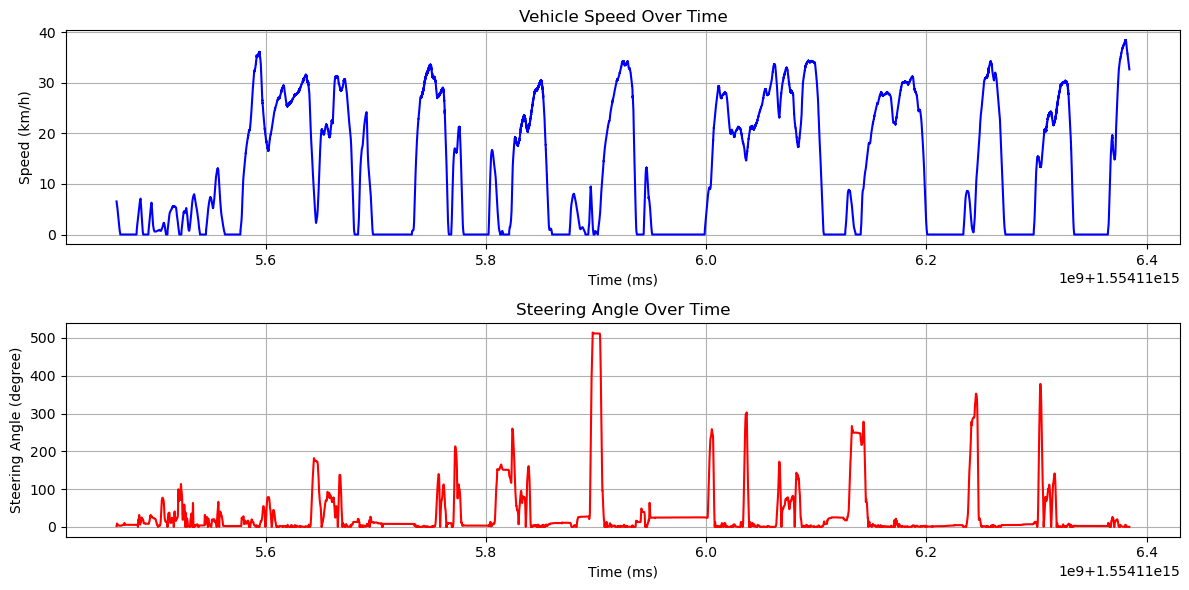

In [13]:
# Plotting Vehicle speed and Steering Angle together
# For Normal driving, we expect to see a correlation between speed and steering angle (e.g. speed decreases during turns)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time_Vx, Vx, label='Vehicle Speed (km/h)', color='blue')
plt.xlabel('Time (ms)')
plt.ylabel('Speed (km/h)')
plt.title('Vehicle Speed Over Time')
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(time_delta, delta, label='Steering Angle (degree)', color='red')
plt.xlabel('Time (ms)')
plt.ylabel('Steering Angle (degree)')
plt.title('Steering Angle Over Time')
plt.grid()
plt.tight_layout()
plt.show()

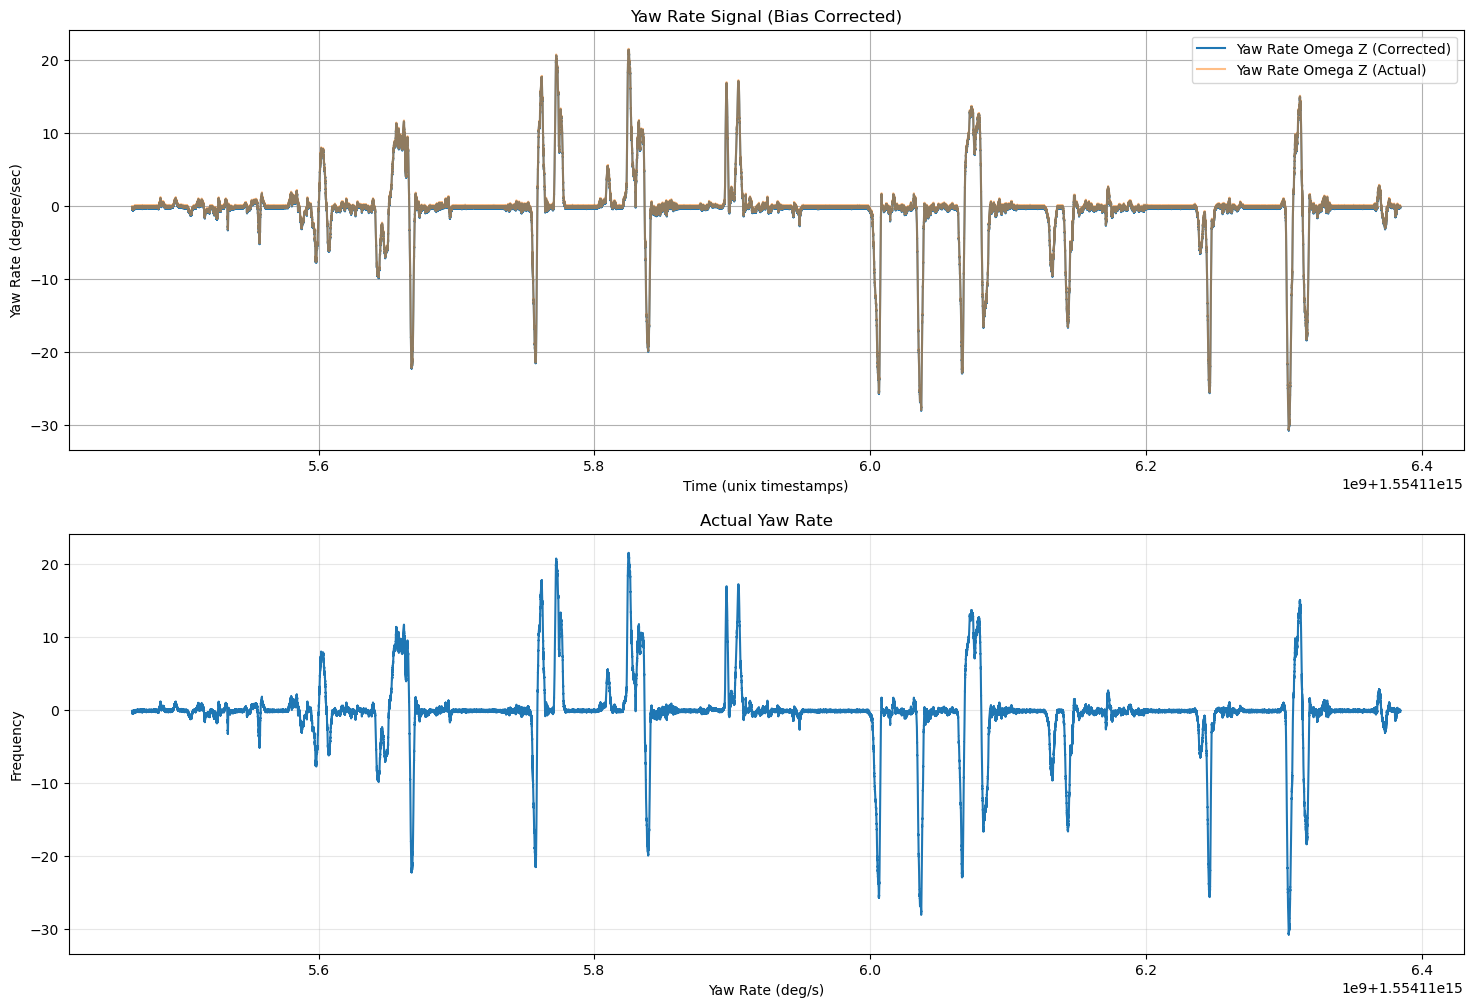

Summary: The yaw rate after bias removal (or adding 0.32, in both cases) show the increment in noise level, see the plot is much thicker than the actual yaw rate


In [14]:
# Omega_z after bias correction
omega_z_corrected = np.array(omega_z) - 0.1157  # 0.32  # Compensate for bias 

plt.figure(figsize=(18, 12))
plt.subplot(2, 1, 1)
plt.plot(time_omega_z, omega_z_corrected, label='Yaw Rate Omega Z (Corrected)')
plt.plot(time_omega_z, omega_z, label='Yaw Rate Omega Z (Actual)', alpha=0.5)
plt.xlabel('Time (unix timestamps)')
plt.ylabel('Yaw Rate (degree/sec)')
plt.title('Yaw Rate Signal (Bias Corrected)')
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(time_omega_z, omega_z)
plt.title('Actual Yaw Rate')
plt.xlabel('Yaw Rate (deg/s)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)   
plt.show()

print("Summary: The yaw rate after bias removal (or adding 0.32, in both cases) show the increment in noise level, see the plot is much thicker than the actual yaw rate")

Number of samples when vehicle is stopped: 15091
Vx during stopped periods (first 10 samples): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Corresponding timestamps (first 10 samples): [0.00000000e+00 2.00030000e-02 4.00040000e-02 ... 9.19627505e+02
 9.19647510e+02 9.19667538e+02]


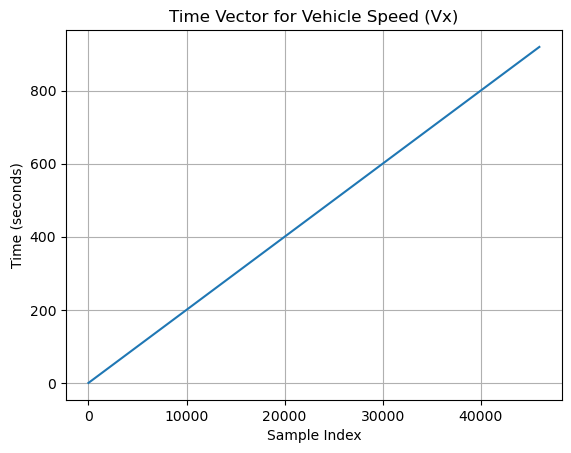

In [15]:
# Function for converting microcontroller unix timestamps to human-readable format

class time_vector:
    def __init__(self, timestamps):
        self.timestamps = timestamps

    def generate_min_max_time(self, unix_timestamps, t_min=None, t_max=None):
        """
        Once you give the value of t_min an dt_max to this function then it 
        will generate  the time vector based on the reference time vector,
        for example based on the highest frquescy sensor signlas, otherwise it is based on 
        it's own timestamps. Meaning that the first value of the time vecctor of that array will be 0.
        """
        # # Convert microcontroller unix time (in microseconds) to seconds
        # unix_time_seconds = self.timestamps / 1_000_000
        # Convert to datetime object
        if isinstance(unix_timestamps, list):
            unix_timestamps = np.array(unix_timestamps)  # Convert list to numpy array for vectorized operations
        
        # Convert microcontroller unix timestamps (in microseconds) to datetime objects
        timestamps = [datetime.datetime.fromtimestamp(ts / 1_000_000) for ts in unix_timestamps]

        if t_min is None:
            t_min = timestamps[0]
        if t_max is None:
            t_max = timestamps[-1]
        return timestamps, t_min, t_max

    def generate_time_vector(self,unix_timestamps):
        """
        Generate a time vector in seconds from a list of datetime objects based on the reference time vector,
        Which gives the minimum and maximum timestamps in the dataset, and calculates the elapsed time in seconds from the minimum timestamp for each timestamp in the list.
        
        Parameters:
        timestamps (list of datetime): List of datetime objects representing timestamps. In datetime.datetime(10,44,23,12,17,44,693201,tzinfo=datetime.timezone.utc), the last part tzinfo=datetime.timezone.utc indicates that the time is in Coordinated Universal Time (UTC).
        t_min (datetime): The minimum timestamp in the dataset.
        t_max (datetime): The maximum timestamp in the dataset.
        
        Returns:
        np.ndarray: Array of time values in seconds.
        
        """
        timestamps, t_min, t_max = self.generate_min_max_time(unix_timestamps)
        t = np.zeros(np.size(timestamps))  # Initialize an empty array to store time values
        for i, dt in enumerate(timestamps):
            
            hour = dt.hour
            minute = dt.minute
            second = dt.second
            microsecond = dt.microsecond

            # For the first timestamp, calculate elapsed time from t_min
            if i == 0:
                if timestamps[0] == t_min and timestamps[-1] == t_max:
                    t_current = 0.0
                else:
                    elapsed_time = (hour - t_min.hour) * 3600 + (minute - t_min.minute) * 60 + (second - t_min.second) + (microsecond - t_min.microsecond) / 1e6
                    t_current = elapsed_time
            else:
                elapsed_time = (hour - t_min.hour) * 3600 + (minute - t_min.minute) * 60 + (second - t_min.second) + (microsecond - t_min.microsecond) / 1e6        # Elapsed time in seconds from t_min
                t_current = elapsed_time  # Update t with the new elapsed time in seconds
            
            # Assign the calculated time to the array
            t[i] = t_current

            # Raise smaller previous time value error
            if i > 0 and t[i] < t[i - 1]:
                raise ValueError("Time value at index {} is smaller than previous value: {} < {}".format(i, t[0], t[i - 1]))
            

        # Raise negative value error
        if t[0] < 0 or np.any(t < 0):
            raise ValueError("Negative time value found at index {}: {}".format(i, t[0]))

        # Raise unequal length error
        if t_min == t[0] and t_max == t[-1] and len(t) != len(timestamps):
            raise ValueError("Length of time vector does not match length of timestamps: {} != {}".format(len(t), len(timestamps)))

        return t
# Yaw rate would be around zero when the vehicle is stopped, so we can check the bias by looking at the mean value of omega_z during periods of low steering angle (delta near zero). Let's identify those periods and calculate the mean yaw rate during those times to confirm the bias.
# Check the vehicle speed and associate yaw, roll and pitch angle with it. When the vehicle is stopped, the yaw rate should be around zero, and any deviation from zero can indicate a bias in the sensor. Let's analyze the data to confirm this.
# Identify the periods when the vehicle is stopped (Vx near zero) and calculate the mean yaw rate during those periods to confirm the bias.
stopped_mask = np.array(Vx) == 0  # Assuming vehicle is stopped when speed is zero
Vx_stopped = np.array(Vx)[stopped_mask]
time_Vx_stopped = np.array(time_Vx)[stopped_mask]
print(f"Number of samples when vehicle is stopped: {len(Vx_stopped)}")
print('Vx during stopped periods (first 10 samples):', Vx_stopped[:10])
time_vx_normal = time_vector(time_Vx).generate_time_vector(time_Vx)
print('Corresponding timestamps (first 10 samples):', time_vx_normal)

# Print the time vector
plt.figure()
plt.plot(time_vx_normal)
plt.title('Time Vector for Vehicle Speed (Vx)')
plt.xlabel('Sample Index')
plt.ylabel('Time (seconds)')
plt.grid()
plt.show()



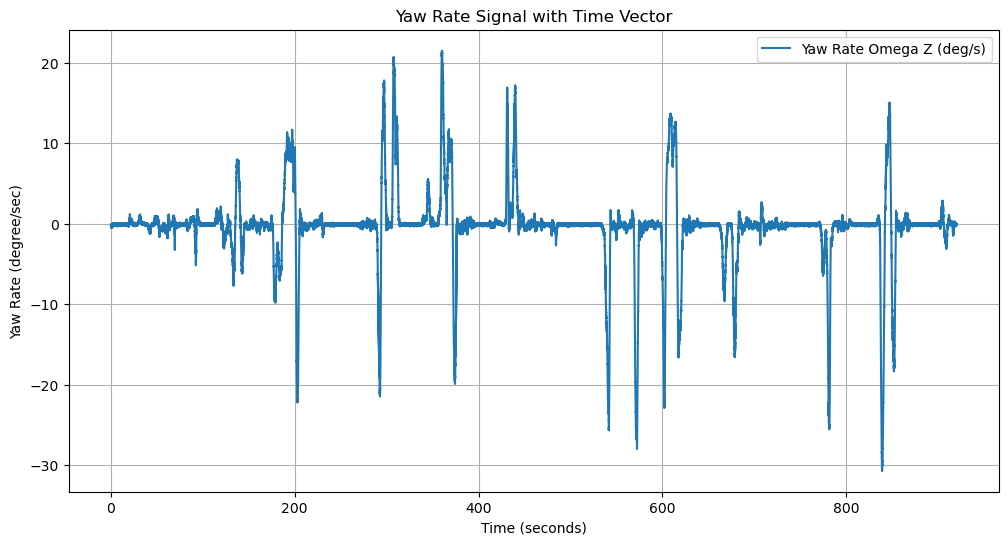

Yaw rate (omega_z) during stopped periods (first 10 samples): [-0.08 -0.07 -0.1  -0.07 -0.07 -0.15 -0.13 -0.07 -0.19 -0.09]


In [16]:
# Generate time vector for all other signals
time_omega_z_normal = time_vector(time_omega_z).generate_time_vector(time_omega_z)

plt.figure(figsize=(12, 6))
plt.plot(time_omega_z_normal, omega_z, label='Yaw Rate Omega Z (deg/s)')
plt.xlabel('Time (seconds)')
plt.ylabel('Yaw Rate (degree/sec)')
plt.title('Yaw Rate Signal with Time Vector')
plt.grid()
plt.legend()
plt.show()

# check the omega_z value associated with the stopped periods
omega_ztime_stop = np.zeros_like(Vx_stopped)
for i in range(len(Vx_stopped)):
    # Find the corresponding timestamp in time_omega_z that matches the stopped period timestamp
    timestamp = time_Vx_stopped[i]
    # Find the index in time_omega_z that is closest to this timestamp
    idx = np.argmin(np.abs(np.array(time_omega_z) - timestamp))
    # Get the corresponding omega_z value
    omega_ztime_stop[i] = omega_z[idx]

print(f"Yaw rate (omega_z) during stopped periods (first 10 samples): {omega_ztime_stop[:10]}")


In [17]:
print("\n" + "="*70)
print("Bias Value for the Yaw Rate According to the Zero Velocity")
print("="*70)

print(f"Mean of yaw rate during stopped periods: {np.mean(omega_ztime_stop):.4f} deg/s")


Bias Value for the Yaw Rate According to the Zero Velocity
Mean of yaw rate during stopped periods: -0.1157 deg/s


METHOD 1: Zero-Velocity Update (ZUPT) — Threshold-based
Instead of exact Vx==0, use a small threshold to catch creeping/noise
  Vx <=  0.0 km/h: bias = -0.1157 deg/s, std = 0.1191, N = 15091
  Vx <=  0.5 km/h: bias = -0.1098 deg/s, std = 0.1635, N = 15457
  Vx <=  1.0 km/h: bias = -0.1037 deg/s, std = 0.2489, N = 16641
  Vx <=  2.0 km/h: bias = -0.1028 deg/s, std = 0.4082, N = 17954

METHOD 2: Median (robust to outliers)
Median is less sensitive to occasional spikes than mean
  Mean bias:          -0.1157 deg/s
  Median bias:        -0.1200 deg/s
  10% Trimmed mean:   -0.1188 deg/s

METHOD 3: Segmented stationary analysis (check for bias drift)
Split stopped periods into segments to see if bias changes over time
  Segment  1: bias = -0.1029 deg/s, duration = 14.9s, N = 745
  Segment  2: bias = -0.0911 deg/s, duration = 4.9s, N = 246
  Segment  3: bias = -0.1174 deg/s, duration = 1.5s, N = 74
  Segment  4: bias = -0.1868 deg/s, duration = 2.0s, N = 100
  Segment  5: bias = -0.1005 deg/s

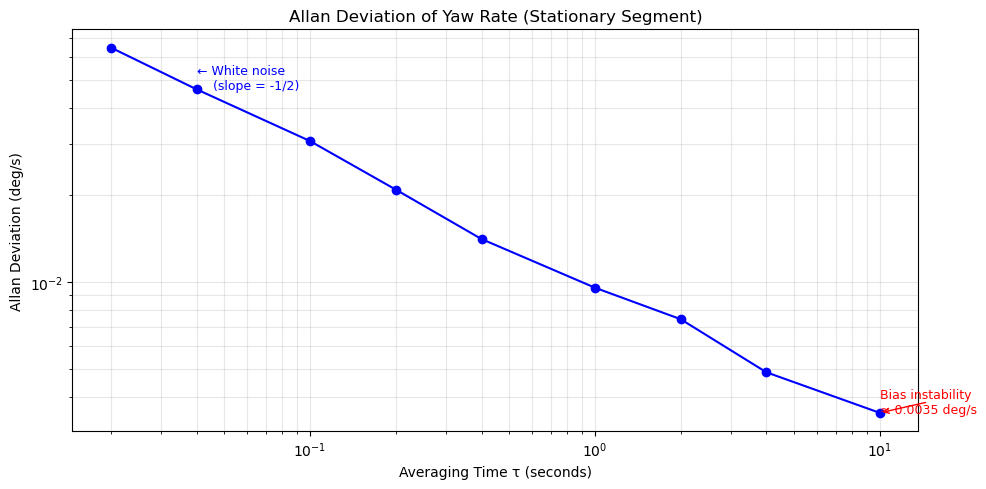

  Bias instability (min Allan deviation): 0.0035 deg/s
  At averaging time τ = 10.00 s

METHOD 5: Combined low-dynamics detection (Vx + low steering + low ay)
Use multiple signals to more reliably identify stationary/straight periods
  Samples passing all conditions: 3100
  Bias (multi-signal mean):   -0.1239 deg/s
  Bias (multi-signal median): -0.1300 deg/s
  Std:                        0.0694 deg/s

SUMMARY OF BIAS ESTIMATES
  Method 1 (ZUPT, Vx==0 mean):      -0.1157 deg/s
  Method 2 (Median):                 -0.1200 deg/s
  Method 2 (Trimmed mean):           -0.1188 deg/s
  Method 3 (Segment avg):            -0.0187 deg/s
  Method 5 (Multi-signal):           -0.1239 deg/s

  ➜ RECOMMENDED BIAS: Use median or multi-signal estimate for robustness


In [18]:
# ============================================================
# ROBUST BIAS ESTIMATION METHODS FOR YAW RATE SENSOR
# ============================================================

omega_z_arr = np.array(omega_z)
Vx_arr = np.array(Vx)
time_omega_arr = np.array(time_omega_z)
time_Vx_arr = np.array(time_Vx)

print("="*70)
print("METHOD 1: Zero-Velocity Update (ZUPT) — Threshold-based")
print("="*70)
print("Instead of exact Vx==0, use a small threshold to catch creeping/noise")

for threshold in [0.0, 0.5, 1.0, 2.0]:
    zupt_mask = Vx_arr <= threshold
    if np.sum(zupt_mask) > 0:
        # Match each ZUPT speed timestamp to nearest omega_z timestamp
        zupt_times = time_Vx_arr[zupt_mask]
        omega_at_zupt = np.array([omega_z_arr[np.argmin(np.abs(time_omega_arr - t))] for t in zupt_times])
        bias = np.mean(omega_at_zupt)
        std = np.std(omega_at_zupt)
        print(f"  Vx <= {threshold:4.1f} km/h: bias = {bias:+.4f} deg/s, std = {std:.4f}, N = {len(omega_at_zupt)}")

print("\n" + "="*70)
print("METHOD 2: Median (robust to outliers)")
print("="*70)
print("Median is less sensitive to occasional spikes than mean")

zupt_mask_strict = Vx_arr == 0
zupt_times_strict = time_Vx_arr[zupt_mask_strict]
omega_at_stop = np.array([omega_z_arr[np.argmin(np.abs(time_omega_arr - t))] for t in zupt_times_strict])

bias_mean = np.mean(omega_at_stop)
bias_median = np.median(omega_at_stop)
bias_trimmed_10 = np.mean(np.sort(omega_at_stop)[len(omega_at_stop)//10 : -len(omega_at_stop)//10])  # 10% trimmed mean

print(f"  Mean bias:          {bias_mean:+.4f} deg/s")
print(f"  Median bias:        {bias_median:+.4f} deg/s")
print(f"  10% Trimmed mean:   {bias_trimmed_10:+.4f} deg/s")

print("\n" + "="*70)
print("METHOD 3: Segmented stationary analysis (check for bias drift)")
print("="*70)
print("Split stopped periods into segments to see if bias changes over time")

# Find contiguous stopped segments
stopped_indices = np.where(Vx_arr == 0)[0]
if len(stopped_indices) > 0:
    # Split into segments where index jumps > 1
    splits = np.where(np.diff(stopped_indices) > 1)[0] + 1
    segments = np.split(stopped_indices, splits)
    
    seg_biases = []
    seg_times = []
    for seg_idx, seg in enumerate(segments):
        if len(seg) >= 5:  # Only segments with enough samples
            seg_times_vx = time_Vx_arr[seg]
            seg_omega = np.array([omega_z_arr[np.argmin(np.abs(time_omega_arr - t))] for t in seg_times_vx])
            seg_bias = np.mean(seg_omega)
            seg_biases.append(seg_bias)
            seg_times.append(np.mean(seg_times_vx))
            print(f"  Segment {seg_idx+1:2d}: bias = {seg_bias:+.4f} deg/s, "
                  f"duration = {(seg_times_vx[-1]-seg_times_vx[0])/1e6:.1f}s, N = {len(seg)}")
    
    if len(seg_biases) > 1:
        print(f"\n  Bias drift range: {np.max(seg_biases)-np.min(seg_biases):.4f} deg/s")
        print(f"  Bias std across segments: {np.std(seg_biases):.4f} deg/s")
        if np.std(seg_biases) < 0.1:
            print("  ✓ Bias is STABLE across segments — constant bias model is valid")
        else:
            print("  ⚠ Bias shows significant drift — consider time-varying bias in EKF")

print("\n" + "="*70)
print("METHOD 4: Allan Variance (noise & bias instability characterization)")
print("="*70)
print("Gold standard for gyroscope characterization")

# Use the longest stationary segment for Allan variance
longest_seg = max(segments, key=len) if len(segments) > 0 else stopped_indices
seg_times_longest = time_Vx_arr[longest_seg]
seg_omega_longest = np.array([omega_z_arr[np.argmin(np.abs(time_omega_arr - t))] for t in seg_times_longest])

# Compute Allan variance
dt_avg = np.mean(np.diff(seg_times_longest)) / 1e6  # Average dt in seconds
taus = []
allan_vars = []
max_cluster = len(seg_omega_longest) // 2

cluster_sizes = [1, 2, 5, 10, 20, 50, 100, 200, 500]
cluster_sizes = [c for c in cluster_sizes if c < max_cluster]

for m in cluster_sizes:
    tau = m * dt_avg
    # Cluster the data
    n_clusters = len(seg_omega_longest) // m
    clustered = np.mean(seg_omega_longest[:n_clusters*m].reshape(n_clusters, m), axis=1)
    # Allan variance = 0.5 * mean of squared differences of consecutive clusters
    av = 0.5 * np.mean(np.diff(clustered)**2)
    taus.append(tau)
    allan_vars.append(av)
    
taus = np.array(taus)
allan_devs = np.sqrt(np.array(allan_vars))

# Plot Allan deviation
plt.figure(figsize=(10, 5))
plt.loglog(taus, allan_devs, 'bo-', linewidth=1.5, markersize=6)
plt.xlabel('Averaging Time τ (seconds)')
plt.ylabel('Allan Deviation (deg/s)')
plt.title('Allan Deviation of Yaw Rate (Stationary Segment)')
plt.grid(True, which='both', alpha=0.3)

# Annotate key regions
if len(taus) > 2:
    plt.annotate('← White noise\n    (slope = -1/2)', 
                xy=(taus[1], allan_devs[1]), fontsize=9, color='blue')
    min_idx = np.argmin(allan_devs)
    plt.annotate(f'Bias instability\n≈ {allan_devs[min_idx]:.4f} deg/s', 
                xy=(taus[min_idx], allan_devs[min_idx]), fontsize=9, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))
plt.tight_layout()
plt.show()

print(f"  Bias instability (min Allan deviation): {np.min(allan_devs):.4f} deg/s")
print(f"  At averaging time τ = {taus[np.argmin(allan_devs)]:.2f} s")

print("\n" + "="*70)
print("METHOD 5: Combined low-dynamics detection (Vx + low steering + low ay)")
print("="*70)
print("Use multiple signals to more reliably identify stationary/straight periods")

delta_arr = np.array(delta)
ay_arr = np.array(ay)
time_delta_arr = np.array(time_delta)
time_ay_arr = np.array(time_ay)

# For each stopped Vx timestamp, also check steering and lateral acceleration
multi_signal_omega = []
for t in zupt_times_strict:
    idx_delta = np.argmin(np.abs(time_delta_arr - t))
    idx_ay = np.argmin(np.abs(time_ay_arr - t))
    idx_omega = np.argmin(np.abs(time_omega_arr - t))
    
    # Require: small steering AND small lateral acceleration
    if np.abs(delta_arr[idx_delta]) < 5.0 and np.abs(ay_arr[idx_ay]) < 0.3:
        multi_signal_omega.append(omega_z_arr[idx_omega])

if len(multi_signal_omega) > 0:
    multi_signal_omega = np.array(multi_signal_omega)
    print(f"  Samples passing all conditions: {len(multi_signal_omega)}")
    print(f"  Bias (multi-signal mean):   {np.mean(multi_signal_omega):+.4f} deg/s")
    print(f"  Bias (multi-signal median): {np.median(multi_signal_omega):+.4f} deg/s")
    print(f"  Std:                        {np.std(multi_signal_omega):.4f} deg/s")
else:
    print("  No samples met all conditions simultaneously")

print("\n" + "="*70)
print("SUMMARY OF BIAS ESTIMATES")
print("="*70)
print(f"  Method 1 (ZUPT, Vx==0 mean):      {bias_mean:+.4f} deg/s")
print(f"  Method 2 (Median):                 {bias_median:+.4f} deg/s")
print(f"  Method 2 (Trimmed mean):           {bias_trimmed_10:+.4f} deg/s")
if len(seg_biases) > 0:
    print(f"  Method 3 (Segment avg):            {np.mean(seg_biases):+.4f} deg/s")
if len(multi_signal_omega) > 0:
    print(f"  Method 5 (Multi-signal):           {np.mean(multi_signal_omega):+.4f} deg/s")
print(f"\n  ➜ RECOMMENDED BIAS: Use median or multi-signal estimate for robustness")

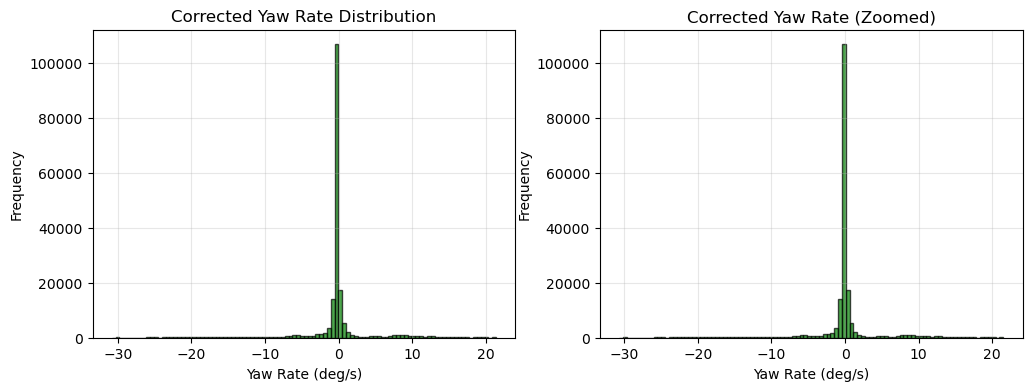

In [19]:
# Comparison of histogram of corrected yaw rate
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(omega_z_corrected, bins=100, alpha=0.7, edgecolor='black', color='green')
plt.title('Corrected Yaw Rate Distribution')
plt.xlabel('Yaw Rate (deg/s)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.hist(omega_z, bins=100, alpha=0.7, edgecolor='black', color='green')
plt.title('Corrected Yaw Rate (Zoomed)')
plt.xlabel('Yaw Rate (deg/s)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()
